# Volcanic Change Detection: Reykjanes Peninsula, Iceland
### SDS210 – Programming with Spatial Data

This notebook implements a change detection workflow to identify and 
quantify landscape changes caused by the 2023–2024 Sundhnúkur eruptions 
on the Reykjanes Peninsula, Iceland.

Three research questions are investigated:
- **RQ1:** Where did the most significant landscape changes occur between 2023 and 2024?
- **RQ2:** How does embedding-based change detection compare to a traditional spectral approach?
- **RQ3:** Which critical infrastructure sites fall within the areas of highest detected landscape change?

## 2. Data Loading


In [24]:
# File paths
from pathlib import Path

# Raster reading and metadata
import rasterio
from rasterio.plot import show
from rasterio.transform import array_bounds

# Numerical calculations
import numpy as np

# Tabular results
import pandas as pd
import geopandas as gpd

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cmcrameri.cm as cmc

import xarray as xr
import rioxarray

In [2]:
# Paths
DATA_RAW       = Path("../data/raw")
DATA_PROCESSED = Path("../data/processed")
OUTPUT_DIR     = Path("../outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

# Raster files exported from GEE
EMB_2023 = DATA_RAW / "AEF_embedding_2023.tif"
EMB_2024 = DATA_RAW / "AEF_embedding_2024.tif"
S2_2023  = DATA_RAW / "S2_composite_2023.tif"
S2_2024  = DATA_RAW / "S2_composite_2024.tif"

# Vector files
BUILDINGS_PRE      = DATA_RAW / "buildings_pre_eruption.geojson"
BUILDINGS_POST     = DATA_RAW / "buildings_post_eruption.geojson"
BUILDINGS_COMBINED = DATA_PROCESSED / "buildings_combined.geojson"

# Study parameters
AOI_NAME  = "Reykjanes Peninsula, Iceland"
YEAR_PRE  = 2023
YEAR_POST = 2024
CHANGE_THRESHOLD = 0.95

print(f"Study area:   {AOI_NAME}")
print(f"Before/after: {YEAR_PRE} → {YEAR_POST}")

# Bounding box (WGS84)
AOI_BOUNDS = {
    "west":  -22.62,
    "east":  -22.15,
    "south":  63.80,
    "north":  63.95
}

Study area:   Reykjanes Peninsula, Iceland
Before/after: 2023 → 2024


In [3]:
# Metadata check of all four rasters
for filepath in [EMB_2023, EMB_2024, S2_2023, S2_2024]:
    with rasterio.open(filepath) as src:
        print(f"{filepath.name}")
        print(f"  CRS:   {src.crs}")
        print(f"  Bands: {src.count}")
        print(f"  Shape: {src.height} x {src.width}")

AEF_embedding_2023.tif
  CRS:   EPSG:32627
  Bands: 64
  Shape: 1723 x 2346
AEF_embedding_2024.tif
  CRS:   EPSG:32627
  Bands: 64
  Shape: 1723 x 2346
S2_composite_2023.tif
  CRS:   EPSG:32627
  Bands: 12
  Shape: 1723 x 2346
S2_composite_2024.tif
  CRS:   EPSG:32627
  Bands: 12
  Shape: 1723 x 2346


## 3. Inspection & Cleaning

### 3.1 Combine building footprints
Merging pre- and post-eruption OSM building datasets to get the most
complete picture of structures that existed before the eruptions. 


In [4]:
# Load both raw building datasets
buildings_pre  = gpd.read_file(DATA_RAW / "buildings_pre_eruption.geojson")
buildings_post = gpd.read_file(DATA_RAW / "buildings_post_eruption.geojson")

# Check CRS of both datasets
print(f"Pre-eruption CRS:  {buildings_pre.crs}")
print(f"Post-eruption CRS: {buildings_post.crs}")

# Combine and remove duplicates by OSM feature ID
buildings_combined = pd.concat([buildings_pre, buildings_post])
buildings_combined = buildings_combined.drop_duplicates(subset=["id"])

# Convert back to GeoDataFrame
buildings_combined = gpd.GeoDataFrame(buildings_combined, crs=buildings_pre.crs)

# Save to processed folder
buildings_combined.to_file(
    DATA_PROCESSED / "buildings_combined.geojson",
    driver="GeoJSON"
)

print(f"Pre-eruption buildings:  {len(buildings_pre)}")
print(f"Post-eruption buildings: {len(buildings_post)}")
print(f"Combined (no doubles):   {len(buildings_combined)}")

# Find buildings in pre that are NOT in post
# These are candidates for destroyed structures
destroyed_candidates = buildings_pre[
    ~buildings_pre["id"].isin(buildings_post["id"])
]

print(f"Buildings that were destroyed (removed from OSM): {len(destroyed_candidates)}")
print(destroyed_candidates[["id", "geometry"]])

Pre-eruption CRS:  EPSG:4326
Post-eruption CRS: EPSG:4326
Pre-eruption buildings:  1306
Post-eruption buildings: 1383
Combined (no doubles):   1390
Buildings that were destroyed (removed from OSM): 7
                 id                                           geometry
15    way/369408544  POLYGON ((-22.4527 63.88162, -22.45262 63.8814...
550   way/414495533  POLYGON ((-22.42082 63.8486, -22.4212 63.8486,...
656   way/414495646  POLYGON ((-22.42163 63.8555, -22.42141 63.8552...
662   way/414495653  POLYGON ((-22.41732 63.84852, -22.41768 63.848...
760   way/493268696  POLYGON ((-22.43586 63.83545, -22.43568 63.835...
1168  way/812387471  POLYGON ((-22.42187 63.84846, -22.42145 63.848...
1196  way/812390811  POLYGON ((-22.4364 63.83517, -22.43618 63.8349...


## 4. RQ1 — Embedding-based change

In [18]:
# Load embedding rasters
with rasterio.open(EMB_2023) as src:
    emb_2023   = src.read(masked=True).astype(np.float32)
    emb_meta = src.profile

with rasterio.open(EMB_2024) as src:
    emb_2024 = src.read(masked=True).astype(np.float32)

# Normalize
norm_2023 = np.linalg.norm(emb_2023, axis=0, keepdims=True)
norm_2024 = np.linalg.norm(emb_2024, axis=0, keepdims=True)
emb_2023 = emb_2023 / np.where(norm_2023 == 0, 1, norm_2023)
emb_2024 = emb_2024 / np.where(norm_2024 == 0, 1, norm_2024)

# Cosine similarity = dot product & embeddings = unit vectors
similarity = np.sum(emb_2023 * emb_2024, axis=0)
change_map = 1 - similarity

# Build mask: any band nodata in either image
nodata_mask = emb_2023.mask.any(axis=0) | emb_2024.mask.any(axis=0)
change_map[nodata_mask] = np.nan

print(f"Min change: {np.nanmin(change_map):.4f}")
print(f"Max change: {np.nanmax(change_map):.4f}")

Min change: 0.0038
Max change: 0.5354


In [14]:
# Save change map for use in RQ3
CHANGE_MAP_PATH = OUTPUT_DIR / "rq1_change_map.tif"
emb_meta.update(count=1, dtype="float32", nodata=np.nan)

with rasterio.open(CHANGE_MAP_PATH, "w", **emb_meta) as dst:
    dst.write(change_map.astype("float32"), 1)

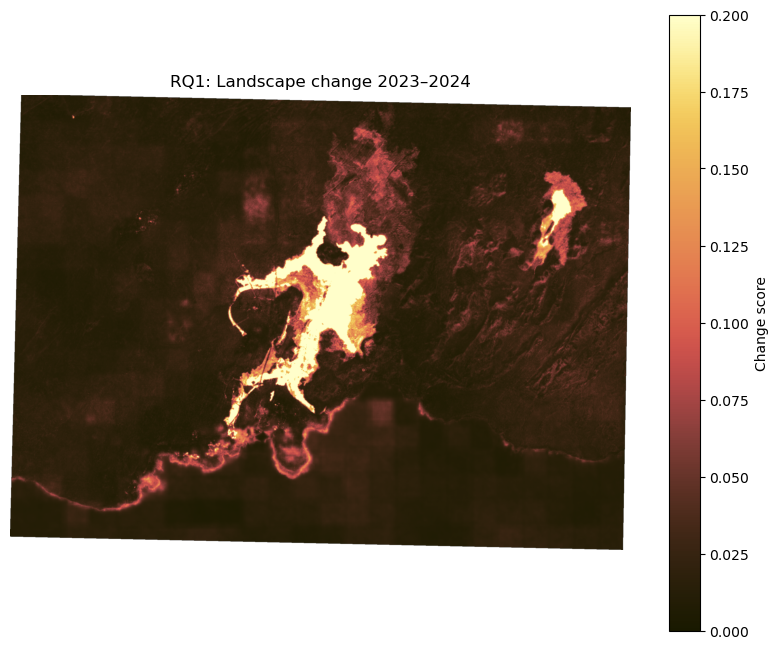

In [15]:
fig, ax = plt.subplots(figsize=(10, 8))
img = ax.imshow(change_map, cmap=cmc.lajolla, vmin=0, vmax=0.2)
fig.colorbar(img, ax=ax, label="Change score")
ax.set_title(f"RQ1: Landscape change {YEAR_PRE}–{YEAR_POST}")
ax.axis("off")
fig.savefig(OUTPUT_DIR / "rq1_change_map.png", dpi=300, bbox_inches="tight")
plt.show()

## 5. RQ2 — Spectral dNBR comparison

In [16]:
# Find NIR and SWIR2 band indices from band names
with rasterio.open(S2_2023) as src:
    band_names = list(src.descriptions)

nir_idx  = band_names.index("B8")  + 1
swir_idx = band_names.index("B12") + 1

with rasterio.open(S2_2023) as src:
    nir_2023  = src.read(nir_idx).astype(float)
    swir_2023 = src.read(swir_idx).astype(float)

with rasterio.open(S2_2024) as src:
    nir_2024  = src.read(nir_idx).astype(float)
    swir_2024 = src.read(swir_idx).astype(float)

with np.errstate(divide="ignore", invalid="ignore"):
    nbr_2023 = (nir_2023 - swir_2023) / (nir_2023 + swir_2023)
    nbr_2024 = (nir_2024 - swir_2024) / (nir_2024 + swir_2024)

# dNBR: after minus before
dnbr = nbr_2023 - nbr_2024

print(f"dNBR min:  {np.nanmin(dnbr):.4f}")
print(f"dNBR max:  {np.nanmax(dnbr):.4f}")

dNBR min:  -0.6816
dNBR max:  0.8536


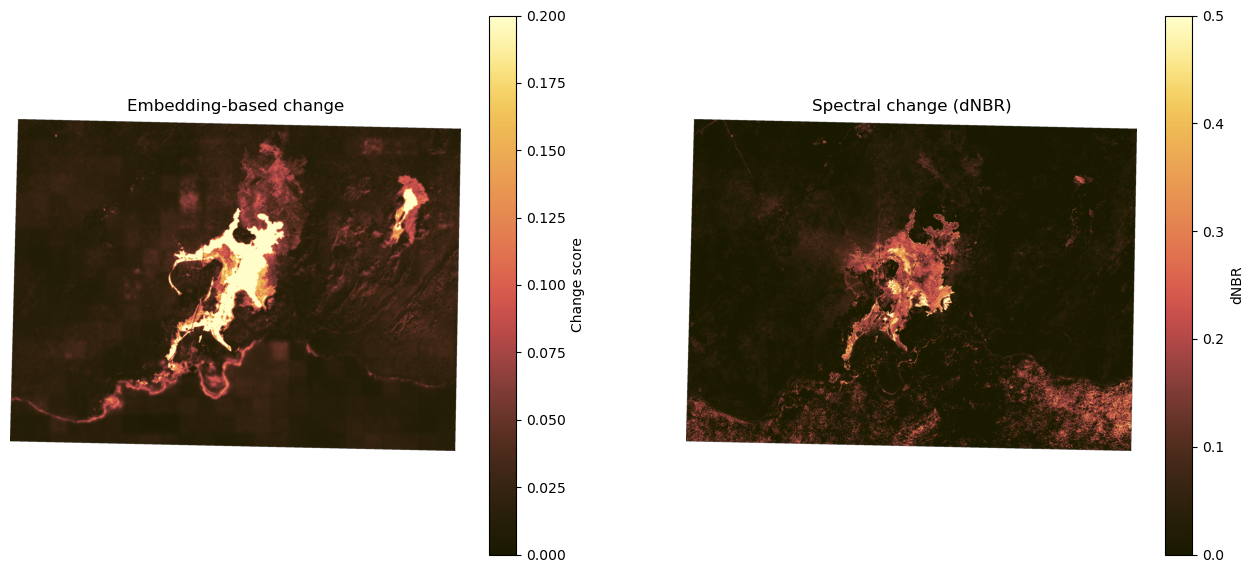

In [17]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(16, 7))

img1 = axs[0].imshow(change_map, cmap=cmc.lajolla, vmin=0, vmax=0.2)
fig.colorbar(img1, ax=axs[0], label="Change score")
axs[0].set_title("Embedding-based change")
axs[0].axis("off")

img2 = axs[1].imshow(dnbr, cmap=cmc.lajolla, vmin=0, vmax=0.5)
fig.colorbar(img2, ax=axs[1], label="dNBR")
axs[1].set_title("Spectral change (dNBR)")
axs[1].axis("off")

fig.savefig(OUTPUT_DIR / "rq2_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

## 6. RQ3 — Infrastructure impact


In [19]:
def get_mean_change(change_raster_path, buildings_gdf):
    """Return GeoDataFrame with mean change score per building footprint."""
    mean_changes = []

    with rasterio.open(change_raster_path) as src:
        for idx, row in buildings_gdf.iterrows():
            try:
                out_image, _ = mask(src, [row.geometry], crop=True, nodata=np.nan)
                mean_val = float(np.nanmean(out_image))
            except Exception:
                # Building lies outside raster extent
                mean_val = np.nan
            mean_changes.append(mean_val)

    result = buildings_gdf.copy()
    result["mean_change"] = mean_changes
    return result

In [20]:
buildings_combined = gpd.read_file(BUILDINGS_COMBINED)
buildings_with_change = get_mean_change(CHANGE_MAP_PATH, buildings_combined)

# Classify each building by its mean change score
buildings_with_change["change_class"] = "low"
buildings_with_change.loc[
    buildings_with_change["mean_change"] >= CHANGE_THRESHOLD, "change_class"
] = "high"

n_high  = (buildings_with_change["change_class"] == "high").sum()
n_total = len(buildings_with_change)
print(f"Total buildings:   {n_total}")
print(f"Severely affected: {n_high} ({100 * n_high / n_total:.1f}%)")

buildings_with_change.to_file(
    OUTPUT_DIR / "rq3_buildings_with_change.geojson",
    driver="GeoJSON"
)

Total buildings:   1390
Severely affected: 0 (0.0%)


In [27]:
# Load combined buildings and reproject to match raster CRS
buildings = gpd.read_file(BUILDINGS_COMBINED).to_crs(emb_meta["crs"])

transform = emb_meta["transform"]
height, width = change_map.shape

# For each building, extract mean change score within its footprint
# Uses windowed reading so only the pixels inside the bounding box
# of each building are processed — much faster than full-raster masking
mean_changes = []

for geom in buildings.geometry:
    # Get pixel window for this building's bounding box
    window = from_bounds(*geom.bounds, transform=transform)
    window = window.intersection(
        rasterio.windows.Window(0, 0, width, height)
    )

    # Skip buildings outside the raster extent
    if window.width < 1 or window.height < 1:
        mean_changes.append(np.nan)
        continue

    # Subset raster to building bounding box
    row_start = int(window.row_off)
    row_end   = int(window.row_off + window.height)
    col_start = int(window.col_off)
    col_end   = int(window.col_off + window.width)
    win_data  = change_map[row_start:row_end, col_start:col_end]

    # Build pixel mask for exact building footprint
    win_transform = rasterio.windows.transform(window, transform)
    footprint_mask = geometry_mask(
        [geom],
        transform=win_transform,
        invert=True,          # True = inside building
        out_shape=win_data.shape
    )

    vals = win_data[footprint_mask & ~np.isnan(win_data)]
    mean_changes.append(float(np.mean(vals)) if len(vals) > 0 else np.nan)

buildings["mean_change"] = mean_changes

# Classify using the 95th percentile of all building change scores
# (absolute threshold of 0.95 is too high given change_map values are 0–0.2)
threshold_value = np.nanpercentile(buildings["mean_change"], CHANGE_THRESHOLD * 100)
print(f"High-change threshold (p{int(CHANGE_THRESHOLD*100)}): {threshold_value:.4f}")

buildings["change_class"] = np.where(
    buildings["mean_change"] >= threshold_value, "high", "low"
)

buildings_with_change = buildings.copy()

# Summary
n_high = (buildings["change_class"] == "high").sum()
n_low  = (buildings["change_class"] == "low").sum()
print(f"High-change buildings: {n_high}")
print(f"Low-change buildings:  {n_low}")
print(buildings_with_change[["id", "mean_change", "change_class"]]
      .sort_values("mean_change", ascending=False)
      .head(10))

NameError: name 'from_bounds' is not defined

/var/folders/md/94r6wf957t32536vlsm17t200000gn/T/ipykernel_49075/3021165987.py:13: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  high_change.plot(ax=ax, color="red",   alpha=0.8, linewidth=0.5)


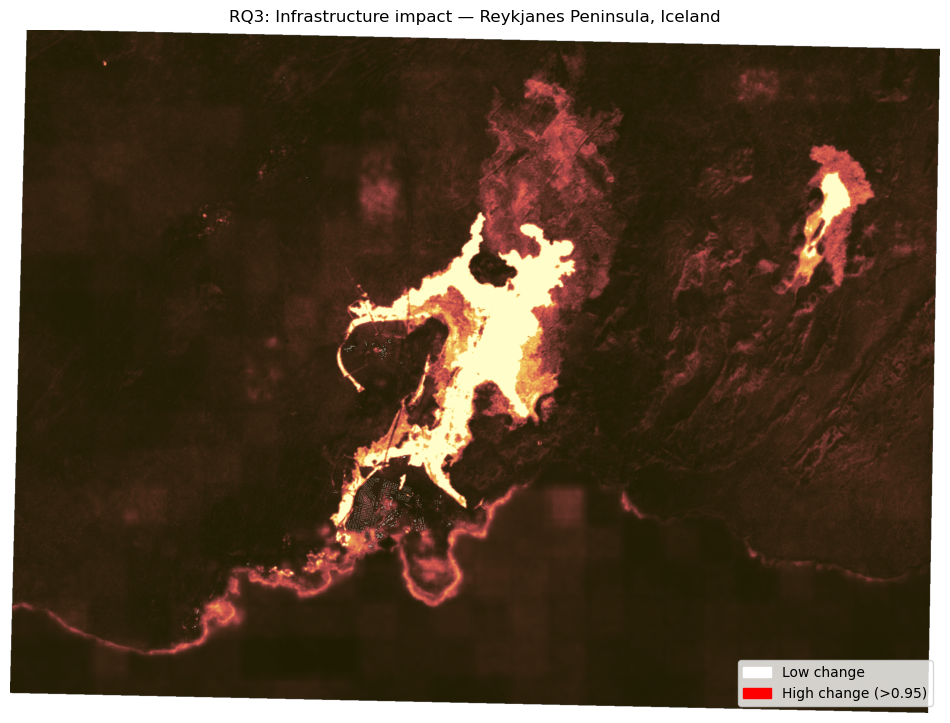

In [26]:
fig, ax = plt.subplots(figsize=(12, 9))

# Plot raster in geographic coordinates
show(change_map, transform=emb_meta["transform"],
     ax=ax, cmap=cmc.lajolla, vmin=0, vmax=0.2)

# Reproject buildings to match raster CRS if needed
raster_crs = emb_meta["crs"]
low_change  = low_change.to_crs(raster_crs)
high_change = high_change.to_crs(raster_crs)

low_change.plot(ax=ax,  color="white", alpha=0.4, linewidth=0.3)
high_change.plot(ax=ax, color="red",   alpha=0.8, linewidth=0.5)

legend_handles = [
    mpatches.Patch(color="white", label="Low change"),
    mpatches.Patch(color="red",   label=f"High change (>{CHANGE_THRESHOLD})")
]
ax.legend(handles=legend_handles, loc="lower right")
ax.set_title(f"RQ3: Infrastructure impact — {AOI_NAME}")
ax.axis("off")
fig.savefig(OUTPUT_DIR / "rq3_infrastructure.png", dpi=300, bbox_inches="tight")
plt.show()

## 7. Summary